<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/src/Topic_Clustring_and_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalations and Imports

In [ ]:
try:
    # Running inside Google Colab → use !pip
    import google.colab
    in_google_colab = True
    print("Running in Colab → installing packages...")
    !pip install -q bertopic
    !pip install -q tweet-preprocessor
    !pip install -q spacy-entity-linker
    !pip install -q emoji
    !pip install sentence-transformers scikit-learn
    !pip install "transformers>=4.40.0" sentencepiece accelerate torch
except ImportError:
    # Not running in Colab
    in_google_colab = False
    pass

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import re
import emoji

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

import spacy

from tqdm.auto import tqdm
from IPython.display import display

# Loading and Exporting
[Labeled Datasets for Research on Information Operations](https://zenodo.org/records/14189193)

## Load Data

In [ ]:
dataset_name = "Labeled_Datasets/Ecuador"  # folder path
file_name = "Ecuador_part_5.gzip.parquet"  # file name

# if run local: put data in "../data/<dataset_name>/<file_name>"
# Recommended: working directory is: "Backbone-Graph/src"

In [ ]:
from pathlib import Path

# Google Colab
if in_google_colab:
    from google.colab import drive
    drive.mount('/content/drive')
    dataset_path = Path("/content/drive/Shareddrives/KeyBoostAuthor") / dataset_name / file_name
    print("Running inside Colab. Loading from Google Drive...")

# Cluster\Local
else:
    dataset_path = Path("../data") / dataset_name / file_name
    print(f"Running on local/cluster.\nLoading data from: {dataset_path}")


# Load the parquet file
df = pd.read_parquet(dataset_path)

# for testing
# df = df.sample(n=10000, random_state=42).copy()

Running on local/cluster.
Loading data from: ../data/Labeled_Datasets/Ecuador/Ecuador_part_5.gzip.parquet


## Output Path


In [ ]:
from datetime import datetime
today = datetime.now().strftime("%Y_%m_%d")


dataset_path = Path(dataset_path)


if in_google_colab:
  output_folder_path = (dataset_path.parents[2] / "Labeled_Dataset_with_Topic_NER" / dataset_path.parent.name / dataset_path.name)
else:
  # working directory is: Backbone-Graph/src
  file_name_no_suffixes = file_name.split(".")[0]
  output_folder_path = Path("../results") / dataset_name / file_name_no_suffixes / today
  # Example: ""../results/Labeled_Datasets/Ecuador/Ecuador_part_4/2025_11_27"



output_folder_path.mkdir(parents=True, exist_ok=True) # Createst the output directory if needed

print(f"output_folder_path = {output_folder_path}")

output_folder_path = ../results/Labeled_Datasets/Ecuador/Ecuador_part_5/2025_11_27


In [ ]:
df.head()

,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,following_count,account_creation_date,is_repost,reposted_accountid,reposted_postid,hashtags,urls,account_mentions,is_control
233553,8210be550701982a1d35c9bde38f12e1f8fe77f648,Gracias mi amado #Perú por toda la preocupación en este lamentable desastre natural ocurrido en #chile! 🙌 #FuerzaChile,15592fcc82d5064a8f4a3b89774e6cd0bbd2118aa0,es,None,None,2015-09-17 23:10:47,5fa9123f60bfeaf7b39b3bac238a7569b805453a34,Diaguita✨ HASTA QUE LA DIGNIDAD SE HAGA COSTUMBRE ♥️🇨🇱,350,817,2010-11-30,True,99295260431455d4adacb29e5a7cccfcca0fef6cf3,62a03140d1d59c81be4dee8779deb6f129f4fadec3,"[Perú, chile, FuerzaChile]",[],[99295260431455d4adacb29e5a7cccfcca0fef6cf3],True
209427,a9c6d650bc5d83464b950b2bde0b927ef60da25ba9,@fccd725c68f13d85f3ab5afe1c4f269aaa04c55dda I can relate w/George my upcoming marriage proposal truly a surprise BUT it's endorsed by d #HolySpirit of God!! #blessedunion!!,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,en,3f579e2e963af90ff34169bc74e56723fb9e952ec2,fccd725c68f13d85f3ab5afe1c4f269aaa04c55dda,2015-05-19 23:48:59,6b33b674860ff49788076a365f06a197764355ea19,"Ever since May 30, 2017 the #HolySpirit has me thinking 24/7 about my 1256acf859fa5d3b9cd0c87aa7930115c2bb9cb0cb cuz politics ruined my career Brooke accepted my #HolySpirit #marriageproposal",1473,4219,2009-03-01,False,None,None,"[HolySpirit, blessedunion]",[],[fccd725c68f13d85f3ab5afe1c4f269aaa04c55dda],True
200199,a8dd204c446ffb7047c57a374dd70b8979b0afa31e,"""@c31c0ce8078f5ba5c90c93aa6b5a32975c32fa82b5: Comandante Hugo Chávez, precursor de la liberación de América Latina https://a8b4f75c94576ea8ba39a908d45515bfa1e207fefb https://824bed881d27c43882779490dab8bef2ea27b2bc9b""",a20fd3edddb315e8a4abfdc03c03ce2a6bf795e456,es,None,None,2015-03-05 04:54:13,961d03b0ff90a98497c4033b11bf6440f7daf1d86f,Madre Venezolana Ingeniera Docente Universitaria IUTCabimas. Que triste me ha dejado tu partida💔,3488,3811,2009-10-08,False,None,None,[],"[https://a8b4f75c94576ea8ba39a908d45515bfa1e207fefb, https://824bed881d27c43882779490dab8bef2ea27b2bc9b]",[c31c0ce8078f5ba5c90c93aa6b5a32975c32fa82b5],True
212447,482825068aa5fefaa6d2dd88e4faf99336383d79ea,"17 new followers in the last week and it is more than just stats, I use it for growing my account! Try it https://8cd98e38678d50286ec04371d9054599a55f199854",28e5b083867d3363db63617cc0f3cfd106abf13d6d,en,None,None,2015-06-13 00:22:00,71cc57155d061d447c2c65756c7dfd6873e403a097,🍃🧚‍♀️🧜‍♀️👑,3618,2055,2009-12-22,False,None,None,[],[https://8cd98e38678d50286ec04371d9054599a55f199854],[],False
239489,45b25d23c7914d72520973703afad4713333344d0d,[Comunicado]\nAnte arremetida calumniosa y atentatoria a dignidad y buen nombre d #Asambleísta @8339a481f9ccf3caef7b1dde5f8920f7f149950160 @f96aa1017e8b8b26d3276009c97035ccb92711eaf0 http…,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,es,None,None,2015-10-19 16:21:00,71cc57155d061d447c2c65756c7dfd6873e403a097,🍃🧚‍♀️🧜‍♀️👑,3618,2055,2009-12-22,True,61a572ca33176e21f363a95acfd60c662647aeb56d,bb6e2711b637c97ac1c713a007960a4733bc9ad133,[Asambleísta],[],"[61a572ca33176e21f363a95acfd60c662647aeb56d, 8339a481f9ccf3caef7b1dde5f8920f7f149950160, f96aa1017e8b8b26d3276009c97035ccb92711eaf0]",False


# Dataset Statistics

In [ ]:
total_posts = len(df)
hashtag_posts = df[df['hashtags'].notna() & (df['hashtags'].str.len() > 0)]
mention_posts = df[df['account_mentions'].notna() & (df['account_mentions'].str.len() > 0)]
url_posts = df[df['urls'].notna() & (df['urls'].str.len() > 0)]

print(f"{'df shape:':<40} {df.shape}")
print(f"{'df posts with hashtags # shape:':<40} {hashtag_posts.shape}  ({len(hashtag_posts)/total_posts*100:.2f}%)")
print(f"{'df posts with account_mentions @ shape:':<40} {mention_posts.shape}  ({len(mention_posts)/total_posts*100:.2f}%)")
print(f"{'df posts with urls shape:':<40} {url_posts.shape}  ({len(url_posts)/total_posts*100:.2f}%)")


print()
print()

print(f"{'**collum name**':<30} **value type**")
for col in df.columns:
    # dtype_str = str(df[col].dtype)  # Convert dtype to string
    # get a sample non-null value if exists
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")


print()
print()
print(df['post_language'].value_counts())

df shape:                                (10000, 19)
df posts with hashtags # shape:          (4529, 19)  (45.29%)
df posts with account_mentions @ shape:  (7276, 19)  (72.76%)
df posts with urls shape:                (6374, 19)  (63.74%)


**collum name**                **value type**
postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | ndarray
urls                           | ndarray
account_mentions               | ndarray
is_control             

# Clean Text

In [ ]:
def clean_url(url_match):

    url = url_match.group(0)

    # 1. Remove protocol (http:// or https://)
    url = re.sub(r"https?://", "", url)
    url = re.sub(r"www\.", "", url)

    # 2. Remove query parameters (?x=1)
    url = url.split("?")[0]

    # 3. Split into components by "/"
    parts = url.split("/")

    # Domain (first part)
    domain = parts[0].replace(".", "_")  # twitter.com → twitter_com

    # First section (second part of the URL)
    if len(parts) > 1 and parts[1].strip() != "":
        section = parts[1].replace(".", "_")
        token = f" URL_{domain}_{section} "
    else:
        token = f" URL_{domain} "

    return token


In [ ]:
def clean_text(text: str) -> str:

    # lowercase
    text = str(text).lower()

    # URLs → domian + first section
    text = re.sub(r"(https?://\S+|www\.\S+)", clean_url, text)

    # Hashtags → HASHTAG_xxx
    text = re.sub(r"#(\w+)", r" HASHTAG_\1 ", text)

    # Mentions → MENTION_xxx
    text = re.sub(r"@(\w+)", r" MENTION_\1 ", text)

    # emoji → EMOJI_xxx
    text = emoji.demojize(text, delimiters=(" EMOJI_", " "))

    # Collapse spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
df["clean_post_text"] = df["post_text"].apply(clean_text)

## Remove Enttities Enteties

In [ ]:
import re
import pandas as pd

URL_RE = re.compile(r"(https?://\S+|www\.\S+)", flags=re.IGNORECASE)
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#(\w+)")
WHITESPACE_RE = re.compile(r"\s+")

def clean_enteties(text: str) -> str:
    """
    Lightly clean a social-media post while keeping it natural
    for machine translation.

    Operations:
    - Replace URLs with <URL>
    - Replace @username with <USER>
    - Turn #hashtag into 'hashtag' (drop the #)
    - Collapse repeated whitespace
    """
    if not isinstance(text, str):
        text = str(text)

    # lowercase
    text = str(text).lower()

    # 1. Normalize URLs
    text = URL_RE.sub("<URL>", text)

    # 2. Normalize mentions
    text = MENTION_RE.sub("<USER>", text)

    # 3. Normalize hashtags: "#Ecuador2025" -> "Ecuador2025"
    text = HASHTAG_RE.sub(r"\1", text)

    # 4. Collapse whitespace
    text = WHITESPACE_RE.sub(" ", text).strip()

    return text

In [ ]:
df["clean_text_no_enteties"] = df["post_text"].astype(str).apply(clean_enteties)

In [ ]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)

df[["post_text", "clean_text_no_enteties"]].sample(n=20)

,post_text,clean_text_no_enteties
233984,You are exactly right! They are scared to death of Trump and they SHOULD be! He is an in your face American! Love it https://4a1f276b21788f4a98a7dff8080834f69495f5648e,you are exactly right! they are scared to death of trump and they should be! he is an in your face american! love it <URL>
224802,"My ""pipe dream"" of good governance is to follow example of Lester B Pearson, Canada's last 100% democratic PM. https://3dd6093effcff94939990f25f36166e9859d7a6f0a","my ""pipe dream"" of good governance is to follow example of lester b pearson, canada's last 100% democratic pm. <URL>"
248125,Me siento muy orgullosa de proyectos hidroeléctricos de mi país #CocaCodoSinclair \n@dcc268e98e9414787c299b3b15e4acdff8b7396e4b @2087399d0b911ed0bb43aa9da21d7301f0a077e56c https…,me siento muy orgullosa de proyectos hidroeléctricos de mi país cocacodosinclair <USER> <USER> https…
214625,"Reunion con comerciantes de Bellavista temas transporte de carga, control de precios seguridad, asuntos interes comun https://7a6b4080d817bd1b7d53f5111629ae0cbe4f13db81","reunion con comerciantes de bellavista temas transporte de carga, control de precios seguridad, asuntos interes comun <URL>"
226085,"@4471877a43c18d164b1530448c8922364fc75eb684 Хах, кошачая ПВО )) https://46d60f728dbcd13e1ed3345617b34379d2a2030440","<USER> хах, кошачая пво )) <URL>"
229579,@6349e7ebc7ca6e56046ceb8156582d56783d302078 Неужели люди реально пишут нечто подобное друг другу https://ec83a06d571f78e81c1872b86690de6267c37fb3fc,<USER> неужели люди реально пишут нечто подобное друг другу <URL>
217555,son 7:10 y todavía sigo en pijama,son 7:10 y todavía sigo en pijama
248808,Siente el espíritu navideño con este mensaje del prefecto @516b0c1e968fe2c596440e5f94a61374a5bf26609b a los guayasenses. ¡Feliz Navidad! https://t.c…,siente el espíritu navideño con este mensaje del prefecto <USER> a los guayasenses. ¡feliz navidad! <URL>
234626,"Contemporary Romance The Only One, enjoy the chemistry and humour kindle &amp; paperback :-https://e0293fc0bd4ced903932b587d97a8867b402d32ef9 https://ced85b9ddc635f8c54c41f92864a843636bbf70db3","contemporary romance the only one, enjoy the chemistry and humour kindle &amp; paperback :-<URL> <URL>"
224001,@f446845e5d230b63e913d7223cdc7560396ac16416 que suerte! ♡👍,<USER> que suerte! ♡👍


# Translation to English

In [ ]:
# map post_language codes to NLLB-200 language codes
# https://dl-translate.readthedocs.io/en/latest/available_languages/

def map_to_nllb_code(lang_code: str) -> str:
    """
    Map your dataset's post_language codes to NLLB-200 language codes.
    If not in mup return the same language code.
    Args:
        lang_code (str): Post language code.
    Returns:
        str: NLLB-200 language code.
    """
    nlln_mapping = {
    # Europe
    "en": "eng_Latn",   # English
    "es": "spa_Latn",   # Spanish
    "pt": "por_Latn",   # Portuguese
    "fr": "fra_Latn",   # French
    "de": "deu_Latn",   # German
    "it": "ita_Latn",   # Italian
    "nl": "nld_Latn",   # Dutch
    "ru": "rus_Cyrl",   # Russian
    "pl": "pol_Latn",   # Polish
    "sv": "swe_Latn",   # Swedish
    "ca": "cat_Latn",    # Catalan
    "cy": "cym_Latn",    # Welsh
    "et": "est_Latn",    # Estonian

    # Middle East
    "ar": "arb_Arab",   # Arabic (MSA)
    "he": "heb_Hebr",   # Hebrew
    "tr": "tur_Latn",   # Turkish
    "fa": "pes_Arab",   # Persian/Farsi

    # South Asia
    "hi": "hin_Deva",   # Hindi
    "ur": "urd_Arab",   # Urdu
    "bn": "ben_Beng",   # Bengali

    # East Asia
    "zh": "zho_Hans",   # Chinese Simplified
    "ja": "jpn_Jpan",   # Japanese
    "ko": "kor_Hang",   # Korean

    # Southeast Asia
    "vi": "vie_Latn",   # Vietnamese
    "id": "ind_Latn",   # Indonesian (modern code)
    "in": "ind_Latn",   # Indonesian (legacy ISO code)
    "tl": "tgl_Latn",   # Tagalog (Philippines)

    # Africa
    "sw": "swh_Latn",   # Swahili

    # Americas
    "qu": "quy_Latn",   # Quechua (Ayacucho)
}


    if lang_code in nlln_mapping:
        return nlln_mapping[lang_code]
    else:
        return lang_code

In [ ]:
df["post_language"] = df["post_language"].apply(map_to_nllb_code)

In [ ]:
# load models

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

MODEL_NAME = "facebook/nllb-200-distilled-600M"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)
translation_pipeline = pipeline("translation", model=model, tokenizer=tokenizer, device=device, max_length=500, batch_size=16)

Using device: cuda


Device set to use cuda


In [ ]:
from tqdm.auto import tqdm


def transformers_translator(
    df: pd.DataFrame,
    translation_pipe,
    text_col: str = "clean_text_no_enteties",
    lang_col: str = "post_language",
    out_col: str = "translated_post",
    target_lang: str = "eng_Latn",
    pivot_lang: str = "spa_Latn",
    backtranslate_same_lang: bool = True,
) -> pd.DataFrame:
    """
    Translate df[text_col] → target_lang using NLLB pipeline.

    If src_lang == target_lang and backtranslate_same_lang=True,
    perform back-translation: target_lang → pivot_lang → target_lang.

    Args:
        df (pd.DataFrame):
            Input DataFrame containing text and language labels.
        translation_pipe (transformers.pipeline):
            Pre-loaded translation pipeline (e.g., NLLB-200).
        text_col (str):
            Column containing original text.
        lang_col (str):
            Column containing language codes matching the pipeline
            (e.g., "spa_Latn", "eng_Latn").
        out_col (str):
            Column name for the translated output.
        target_lang (str):
            Target language code (default: "eng_Latn").
        pivot_lang (str):
            Pivot language code for back-translation (default: "spa_Latn").
        backtranslate_same_lang (bool):
            If True, back-translate rows where src_lang == target_lang.

    Returns:
        pd.DataFrame:
            A DataFrame with the same index as df and one column (out_col).
    """

    result_df = pd.DataFrame(index=df.index)
    result_df[out_col] = None

    # Iterate per language with progress bar
    for src_lang, group in tqdm(df.groupby(lang_col), desc="Translating by language"):

        # Build a list[str]
        texts = group[text_col].astype(str).tolist()

        # Keep the original indexes so we can assign back later
        indexes = group.index.to_list()

        translated = []  # empty means "no translation done"

        # Case 1: normal translation src_lang -> target_lang
        if src_lang != target_lang:
            print(f"{len(texts)} posts: {src_lang} → {target_lang}")
            outputs = translation_pipe(
                texts,
                src_lang=src_lang,
                tgt_lang=target_lang,
            )
            translated = [o["translation_text"] for o in outputs]

        # Case 2: back-translation target_lang -> pivot_lang -> target_lang
        if (src_lang == target_lang) and backtranslate_same_lang:
            print(f"{len(texts)} posts: {target_lang} → {pivot_lang} → {target_lang}")
            pivot_outputs = translation_pipe(
                texts,
                src_lang=target_lang,
                tgt_lang=pivot_lang,
            )
            pivot_texts = [o["translation_text"] for o in pivot_outputs]

            back_outputs = translation_pipe(
                pivot_texts,
                src_lang=pivot_lang,
                tgt_lang=target_lang,
            )
            translated = [o["translation_text"] for o in back_outputs]

        if translated:
            result_df.loc[indexes, out_col] = translated

    return result_df

In [ ]:
print(f"df shape: {df.shape}")
translated_df = transformers_translator(df, translation_pipeline)
df = df.drop(columns=["translated_post"], errors="ignore") # Drop the old column if exist
df = df.join(translated_df)

df shape: (10000, 21)


Translating by language:   0%|          | 0/37 [00:00<?, ?it/s]

35 posts: arb_Arab → eng_Latn
93 posts: bg → eng_Latn
31 posts: cat_Latn → eng_Latn
2 posts: cs → eng_Latn
15 posts: da → eng_Latn
11 posts: deu_Latn → eng_Latn
8 posts: el → eng_Latn
1658 posts: eng_Latn → spa_Latn → eng_Latn


Your input_length: 500 is bigger than 0.9 * max_length: 500. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)


5 posts: est_Latn → eng_Latn
5 posts: eu → eng_Latn
5 posts: fi → eng_Latn
81 posts: fra_Latn → eng_Latn
4 posts: hin_Deva → eng_Latn
6 posts: ht → eng_Latn
1 posts: hu → eng_Latn
50 posts: ind_Latn → eng_Latn
50 posts: ita_Latn → eng_Latn
34 posts: jpn_Jpan → eng_Latn
8 posts: kor_Hang → eng_Latn
1 posts: lt → eng_Latn
3 posts: nld_Latn → eng_Latn
3 posts: no → eng_Latn
23 posts: pol_Latn → eng_Latn
147 posts: por_Latn → eng_Latn
7 posts: ro → eng_Latn
1032 posts: rus_Cyrl → eng_Latn
1 posts: sk → eng_Latn
6177 posts: spa_Latn → eng_Latn
2 posts: sr → eng_Latn
2 posts: swe_Latn → eng_Latn
17 posts: tgl_Latn → eng_Latn
15 posts: th → eng_Latn
23 posts: tur_Latn → eng_Latn
1 posts: uk → eng_Latn
427 posts: und → eng_Latn
15 posts: vie_Latn → eng_Latn
2 posts: zho_Hans → eng_Latn


In [ ]:
pd.set_option("display.width", 3000)
pd.set_option("display.max_colwidth", 1500)

df.sample(10)[["clean_text_no_enteties", "translated_post"]]

,clean_text_no_enteties,translated_post
246360,"porque, si obligados por las circunstancias, debido a la avalancha de votos, deciden respetar la voluntad del pueblo habrá valido la pena!","Because if forced by the circumstances, because of the avalanche of votes, they decide to respect the will of the people it will have been worth it!"
234896,agendapresidencial lunes 21 ecuadorpaísdediálogo <USER> <USER> <USER> cambiodemando <URL>,President's agenda on Monday 21 February
200441,aun las entradas siguen en venta!! hagamos sold out!!!!,Even the tickets are still on sale!! let's sell out!!!!
243480,inaugurada autopista cimarrón andresote y distribuidor palma sola en carabobo <URL> … <URL>,Cimarron andresote motorway opened and palma alone distributor in carabobo <URL> ... <URL>
233391,"vivacuba medidas de eeuu no han modificado aplicación del bloqueo, afirmó bruno rodríguez [+… <URL> vivafidel vivaraul","EU measures have not modified the application of the blockade, said Bruno Rodriguez [+... <URL> vivafidel vivaraul"
216731,icymi: secret emails show hillary clinton tied to benghazi cover up: <URL> via <USER>,ICMI: secret emails showing Hillary Clinton linked to Benghazi cover-up: <URL> through <USER>
229995,<USER> holasoygerman <USER> streamys <URL>,<USER> holasoundygerman <USER> streamys <URL>
221365,¿cómo se llama cuando un grupo de personas de una ideología concreta asesina a quienes no se someten a la misma? terrorismomachista,What do you call it when a group of people of a particular ideology kills people who don't submit to it?
215211,ciudadanía sentada en una mesa dialogando y no en las calles gritando fueracorreafuera 8) y final,Citizens sitting at a table talking and not on the streets screaming outside (8) and ending
234902,"prefecto <USER> ratificó que pedirá un mayor control a la policía, para evitar nuevas agresiones en consulta en…","The USER prefect confirmed that he will ask for greater control of the police, to prevent further aggression in consultation in..."


# Remove Engllish Stopwords

In [ ]:
from nltk.corpus import stopwords
import nltk

In [ ]:
nltk.download('stopwords')

EXTRA_STOPWORDS = [
    'he', 'she', 'they', 'you', 'i', 'we', 'im', 'hes', 'shes', 'its', 'rt', 'amp', 're',
    'theyre', 'dont', 'doesnt', 'would', 'could', 'like', 'know', 'say', 'said', 'one',
    'look', 'looks', 'think', 'oh', 'yeah', 'guy', 'gonna', 'thing', 'someone', 'people',
    'get', 'got', 'thats', 'just', 'really', 'even', 'still', 'want', 'need', 'needs',
    'me', 'to', 'you', 'the', 'that', 'be', 'my', 'get', 'in', 'and',
     'rt', 'the', 'https', 'to', 'my', 'it', 'on', 'you', 'of', 'for', 'https', 'http', 'RT'
]
all_stopwords_english = set(stopwords.words('english') + EXTRA_STOPWORDS)

def remove_stopwords(text):
    return " ".join([w for w in text.lower().split() if w not in all_stopwords_english])


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/amitner/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df["clean_post_text"] = df["clean_post_text"].apply(remove_stopwords)

In [ ]:
df[["post_text", "clean_post_text"]].head(20)

,post_text,clean_post_text
233553,Gracias mi amado #Perú por toda la preocupación en este lamentable desastre natural ocurrido en #chile! 🙌 #FuerzaChile,gracias mi amado hashtag_perú por toda la preocupación en este lamentable desastre natural ocurrido en hashtag_chile ! emoji_raising_hands hashtag_fuerzachile
209427,@fccd725c68f13d85f3ab5afe1c4f269aaa04c55dda I can relate w/George my upcoming marriage proposal truly a surprise BUT it's endorsed by d #HolySpirit of God!! #blessedunion!!,mention_fccd725c68f13d85f3ab5afe1c4f269aaa04c55dda relate w/george upcoming marriage proposal truly surprise endorsed hashtag_holyspirit god!! hashtag_blessedunion !!
200199,"""@c31c0ce8078f5ba5c90c93aa6b5a32975c32fa82b5: Comandante Hugo Chávez, precursor de la liberación de América Latina https://a8b4f75c94576ea8ba39a908d45515bfa1e207fefb https://824bed881d27c43882779490dab8bef2ea27b2bc9b""",""" mention_c31c0ce8078f5ba5c90c93aa6b5a32975c32fa82b5 : comandante hugo chávez, precursor de la liberación de américa latina url_a8b4f75c94576ea8ba39a908d45515bfa1e207fefb url_824bed881d27c43882779490dab8bef2ea27b2bc9b"""
212447,"17 new followers in the last week and it is more than just stats, I use it for growing my account! Try it https://8cd98e38678d50286ec04371d9054599a55f199854","17 new followers last week stats, use growing account! try url_8cd98e38678d50286ec04371d9054599a55f199854"
239489,[Comunicado]\nAnte arremetida calumniosa y atentatoria a dignidad y buen nombre d #Asambleísta @8339a481f9ccf3caef7b1dde5f8920f7f149950160 @f96aa1017e8b8b26d3276009c97035ccb92711eaf0 http…,[comunicado] ante arremetida calumniosa atentatoria dignidad buen nombre hashtag_asambleísta mention_8339a481f9ccf3caef7b1dde5f8920f7f149950160 mention_f96aa1017e8b8b26d3276009c97035ccb92711eaf0 http…
242724,#JeSuisParis #JeSuisParis #JeSuisParis #JeSuisParis ####################,hashtag_jesuisparis hashtag_jesuisparis hashtag_jesuisparis hashtag_jesuisparis ####################
210822,Let's give some positive vibes &amp; #Support 2 @f8265eba05e3a55d057c3fb22a7d427b939d3fea91 &amp; #Palestine in the upcoming #FIFA vote! ☺\n\n#RedCardIsrael https://6d8cbb605cb9e91e73cfcc088b07d14f604447017f,let's give positive vibes &amp; hashtag_support 2 mention_f8265eba05e3a55d057c3fb22a7d427b939d3fea91 &amp; hashtag_palestine upcoming hashtag_fifa vote! emoji_smiling_face hashtag_redcardisrael url_6d8cbb605cb9e91e73cfcc088b07d14f604447017f
249498,Very Interesting! Child-seat manufacturer Dorel utilizes the same technology found in @cad8661b7fb8592d186751c40e4852617a9d839b93 race seats. https://7d9a660591f0208084f609c322195006a8598de004,interesting! child-seat manufacturer dorel utilizes technology found mention_cad8661b7fb8592d186751c40e4852617a9d839b93 race seats. url_7d9a660591f0208084f609c322195006a8598de004
204144,"Hoy en #NoticiasTVV Declaraciones del dirigente @df7806685b99a2614c24e63aab490130ca10c395db, del presidente de Empresas Polar, Lorenzo Mendonza (1/2)","hoy en hashtag_noticiastvv declaraciones del dirigente mention_df7806685b99a2614c24e63aab490130ca10c395db , del presidente de empresas polar, lorenzo mendonza (1/2)"
236958,"""Aquellos de luto, podrán vestir luto eterno, porque el pasado no volverá"" @2087399d0b911ed0bb43aa9da21d7301f0a077e56c #ELAP2015","""aquellos de luto, podrán vestir luto eterno, porque el pasado volverá"" mention_2087399d0b911ed0bb43aa9da21d7301f0a077e56c hashtag_elap2015"


# English Topic Clustering

## Utils


In [ ]:
def make_topic_stats(df, topic_col_name):
    """
    Calculate per-topic post counts.

    Args:
        df (pd.DataFrame): Data with topics and 'is_control'.
        topic_col_name (str): Column name of topic labels.

    Returns:
        topic_stats (pd.DataFrame): Colums total_count, io_Count, legitimate_posts, io_percent.
    """
    topic_stats = (
        df.groupby(topic_col_name)
          .agg(
              total_count=(topic_col_name, "count"),
              io_count=("is_control", lambda x: (~x).sum())
          )
          .reset_index()
    )
    topic_stats["legitimate_posts"] = topic_stats["total_count"] - topic_stats["io_count"]
    topic_stats["io_percent"] = topic_stats["io_count"] / topic_stats["total_count"] * 100
    return topic_stats

In [ ]:
def plot_topic_stats(topic_stats, topic_col_name, model_name, output_folder_path = ""):
    """
    Plot stacked IO vs legitimate post counts per topic.
    Saves the fig to output_path if provided.

    Args:
        topic_stats (pd.DataFrame): Output of make_topic_stats().
        topic_col_name (str): Topic column to plot.
        output_folder_path (str): Path to *folder* save the plot.

    Returns:
        None
    """
    topics = topic_stats[topic_col_name]
    io_count = topic_stats["io_count"]
    legitimate_count = topic_stats["legitimate_posts"]

    plt.figure(figsize=(12, 6))

    # 🔴 Bottom: IO posts
    plt.bar(topics, io_count, label="IO posts", color="red")

    # 🔵 Top: Non-IO posts stacked above IO
    plt.bar(topics, legitimate_count, bottom=io_count, label="Non-IO posts")

    plt.title(f"Post Count per Topic ({model_name})")
    plt.xlabel("Topic ID")
    plt.ylabel("Number of Posts")
    plt.text(0.98, 0.82, f"Total posts: {topic_stats['Count'].sum()}", ha="right", va="bottom", transform=plt.gca().transAxes)
    plt.xticks(topics)
    plt.grid(axis="y")
    plt.legend()
    plt.tight_layout()


    if output_folder_path:
        plot_file_path = output_folder_path / (f"{model_name}_topic_clustering.png")
        plt.savefig(plot_file_path, dpi=300)
        print(f"plot is saved to {plot_file_path}")


    plt.show()

In [ ]:
clean_posts_text_lst = df["clean_post_text"].to_list()

In [ ]:
from sklearn.preprocessing import normalize

# Load model
model = SentenceTransformer("digio/Twitter4SSE")

# Embeddings
embeddings = model.encode(clean_posts_text_lst, show_progress_bar=True)
embeddings = normalize(embeddings)

No sentence-transformers model found with name digio/Twitter4SSE. Creating a new one with mean pooling.


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

## BERTopic

In [ ]:
def english_BERTopic_modeling(posts_text_lst, embeddings, output_folder_path= "", min_topic_size=400):
    """
    Run BERTopic using precomputed embeddings.

    Args:
        posts_text_lst (list[str]): English text posts.
        embeddings (np.ndarray): Precomputed embeddings aligned with the posts.
        min_topic_size (int): Minimum cluster size.

    Returns:
        topics, probs, topic_model
    """
    topic_model = BERTopic(
        language="english",
        min_topic_size=min_topic_size,
        verbose=True # show logs
    )

    # save model to folder
    if output_folder_path:
        topic_model.save(output_folder_path / "BERTopic_model")
        print(f"BERTopic model is saved to {output_folder_path}")

    topics, probs = topic_model.fit_transform(posts_text_lst, embeddings)

    return topics, probs, topic_model


In [ ]:
BERTopic_topic, BERT_probs, BERTopic_model = english_BERTopic_modeling(clean_posts_text_lst, embeddings, output_folder_path)

df["BERTopic_topic"] = BERTopic_topic

BERTopic_model.get_topic_info()

2025-11-27 18:53:02,029 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
2025-11-27 18:53:02,037 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


BERTopic model is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_5/2025_11_27


2025-11-27 18:53:25,419 - BERTopic - Dimensionality - Completed ✓
2025-11-27 18:53:25,420 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-27 18:53:27,063 - BERTopic - Cluster - Completed ✓
2025-11-27 18:53:27,067 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-27 18:53:27,223 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,2887,-1_hashtagtuitutil_unfollowers_seguidores_nuevos,"[hashtagtuitutil, unfollowers, seguidores, nuevos, emojifacewithtearsofjoy, hashtagrt, en, url46d60f728dbcd13e1ed3345617b34379d2a2030440, de, emojiheartsuit]","[mention_b292eca575486f3fc6d3432ebd95fe4d1bb21f1876 gracias por seguirme, en breve te devuelvo follow :) hashtag_tuitutil url_43be7c8485378857aa4b1b346df29c36d7e573555e, mention_7e1066c2812e5089de5670d7c321b105571dd58f6a gracias por seguirme, en breve te devuelvo follow :) hashtag_tuitutil url_6684f89f522e889a4444d9a1682d459eeded835f37, mention_399063ca1fee762384239df715655357d4ea2ab722 gracias por seguirme, en breve te devuelvo follow :) hashtag_tuitutil url_83c5d774da3d987284d94be529fb8ec2becd3c4341]"
1,0,4690,0_de_la_en_el,"[de, la, en, el, que, los, del, para, con, por]","[""la libertaddeprensaeslamáscaradlibertaddeempresa""◆ mention_6f95990bbe9e7decd80cbab6bf5d06df8145b27825 ◆ mention_917048be3d41c77b9ede8ee3cbad03b251dab8cdad mention_86331734f7adb6a4123dec48365e7e54d1d46c92d4 mention_c23a01498bd0e52f0582f48be255332815b435c97f mention_c1f78bd850d5f905f8ed2cbd35d548409d9b4f5f27 mention_a914185c2f4104a779cc8c0bef07030124b4f4308a url_5b09b18f9bcbc39fdcb1414b65ee1e855a99d27141, la aplicación de estrategias de conservación evitará la extinción de vida silvestre. sé parte de la hashtag_generaciónverde url_78de03ebb26650e74e850833711642636b9f92947f, sucedió en el gobierno de hashtag_eloyalfaro url_3e0047fa63f98c6b743967b46d30a79ae4a123089e]"
2,1,1485,1_de_la_que_el,"[de, la, que, el, en, los, es, se, un, con]","[la mala prensa es la que nos “critica”: es la que tumbó allende, la que desinforma, la que practica la censura conveniencia., hoy en el día del niño que está por nacer, recordamos la fuerza del amor la importancia de la vida. ya 7 meses con mi segundo corazón♡, es claro que hay una conspiración en marcha. la violencia de los de siempre es inaudita. ¡el pasado, volverá! ¡somos má…]"
3,2,938,2_hashtagpjnet_amp_photo_today,"[hashtagpjnet, amp, photo, today, mention2b8885b22522208823b6eab4ca07dc613d829755b9, posted, via, new, mt, news]","[posted photo url_768bb093ffcf4950c4b1c0d07b8ff92e0f52cfca44, url_2b58cb9fb2b3b31bcf7e70328f89d18ddc9fd213dc 20% discount today!! coupon: dnom9r82 new hashtag_amazon !!! great hashtag_kitchen hashtag_knife !!, url_2b58cb9fb2b3b31bcf7e70328f89d18ddc9fd213dc 20% discount today!! coupon: dnom9r82 new hashtag_amazon !!! great hashtag_kitchen hashtag_knife !!]"


plot is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_5/2025_11_27/BERTopic_topic_clustering.png


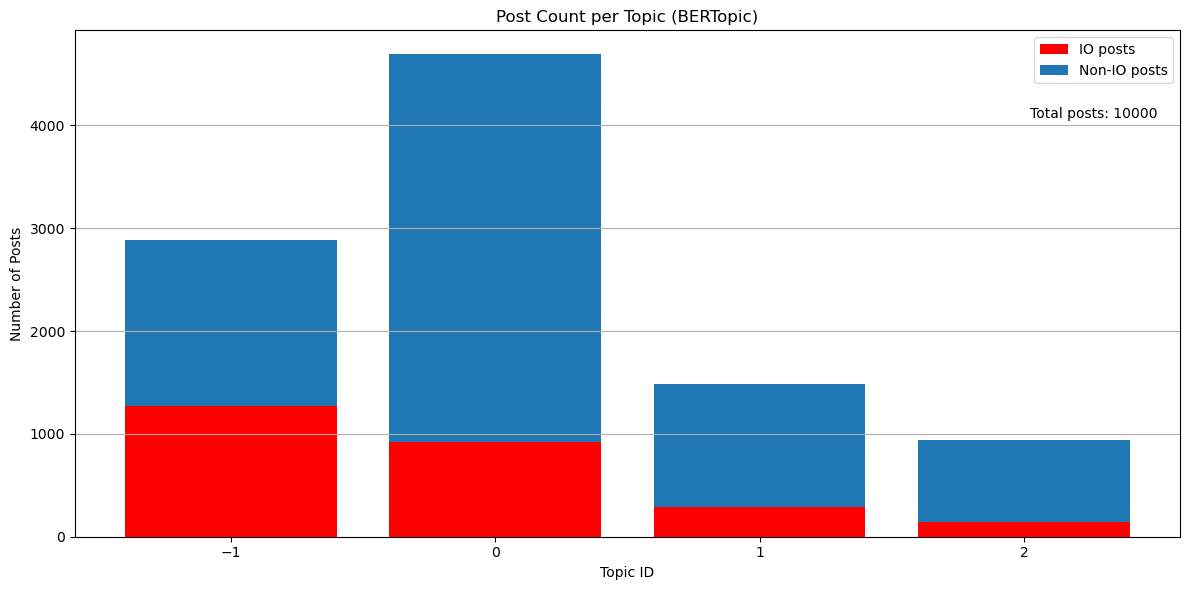

In [ ]:
topic_col_name = "BERTopic_topic"
BERT_topic_stats = make_topic_stats(df, topic_col_name)
plot_topic_stats(BERT_topic_stats, topic_col_name, "BERTopic", output_folder_path)

In [ ]:
from IPython.display import display

try:
    fig = BERTopic_model.visualize_topics(custom_labels=True)
    display(fig)   # show it
except Exception as e:
    print("Not enough topics for visualization")
    print("Error:", e)

Not enough topics for visualization
Error: Cannot use scipy.linalg.eigh for sparse A with k >= N. Use scipy.linalg.eigh(A.toarray()) or reduce k.


/home/amitner/.local/lib/python3.12/site-packages/umap/spectral.py:519: RuntimeWarning:

k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.



## K-Means

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def auto_kmeans_topics(embeddings, k_min=4, k_max=40, step = 2):
    best_k = None
    best_score = -1
    best_labels = None

    for k in range(k_min, k_max + 1, step):
        km = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = km.fit_predict(embeddings)
        score = silhouette_score(embeddings, labels)

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    return best_labels, best_k

In [ ]:
# Add to df
labels, best_k = auto_kmeans_topics(embeddings)
df["K_Means_topic"] = labels
print(f"Best k: {best_k}")
df.head()

Best k: 4


,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,...,reposted_postid,hashtags,urls,account_mentions,is_control,clean_post_text,clean_text_no_enteties,translated_post,BERTopic_topic,K_Means_topic
233553,8210be550701982a1d35c9bde38f12e1f8fe77f648,Gracias mi amado #Perú por toda la preocupación en este lamentable desastre natural ocurrido en #chile! 🙌 #FuerzaChile,15592fcc82d5064a8f4a3b89774e6cd0bbd2118aa0,spa_Latn,None,None,2015-09-17 23:10:47,5fa9123f60bfeaf7b39b3bac238a7569b805453a34,Diaguita✨ HASTA QUE LA DIGNIDAD SE HAGA COSTUMBRE ♥️🇨🇱,350,...,62a03140d1d59c81be4dee8779deb6f129f4fadec3,"[Perú, chile, FuerzaChile]",[],[99295260431455d4adacb29e5a7cccfcca0fef6cf3],True,gracias mi amado hashtag_perú por toda la preocupación en este lamentable desastre natural ocurrido en hashtag_chile ! emoji_raising_hands hashtag_fuerzachile,gracias mi amado perú por toda la preocupación en este lamentable desastre natural ocurrido en chile! 🙌 fuerzachile,Thank you my beloved Peru for all your concern about this unfortunate natural disaster in Chile!,1,0
209427,a9c6d650bc5d83464b950b2bde0b927ef60da25ba9,@fccd725c68f13d85f3ab5afe1c4f269aaa04c55dda I can relate w/George my upcoming marriage proposal truly a surprise BUT it's endorsed by d #HolySpirit of God!! #blessedunion!!,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,eng_Latn,3f579e2e963af90ff34169bc74e56723fb9e952ec2,fccd725c68f13d85f3ab5afe1c4f269aaa04c55dda,2015-05-19 23:48:59,6b33b674860ff49788076a365f06a197764355ea19,"Ever since May 30, 2017 the #HolySpirit has me thinking 24/7 about my 1256acf859fa5d3b9cd0c87aa7930115c2bb9cb0cb cuz politics ruined my career Brooke accepted my #HolySpirit #marriageproposal",1473,...,None,"[HolySpirit, blessedunion]",[],[fccd725c68f13d85f3ab5afe1c4f269aaa04c55dda],True,mention_fccd725c68f13d85f3ab5afe1c4f269aaa04c55dda relate w/george upcoming marriage proposal truly surprise endorsed hashtag_holyspirit god!! hashtag_blessedunion !!,<USER> i can relate w/george my upcoming marriage proposal truly a surprise but it's endorsed by d holyspirit of god!! blessedunion!!,<USER> I can relate to George my next marriage proposal really a surprise but it's backed by God's holy spirit!! blessed union!!,2,3
200199,a8dd204c446ffb7047c57a374dd70b8979b0afa31e,"""@c31c0ce8078f5ba5c90c93aa6b5a32975c32fa82b5: Comandante Hugo Chávez, precursor de la liberación de América Latina https://a8b4f75c94576ea8ba39a908d45515bfa1e207fefb https://824bed881d27c43882779490dab8bef2ea27b2bc9b""",a20fd3edddb315e8a4abfdc03c03ce2a6bf795e456,spa_Latn,None,None,2015-03-05 04:54:13,961d03b0ff90a98497c4033b11bf6440f7daf1d86f,Madre Venezolana Ingeniera Docente Universitaria IUTCabimas. Que triste me ha dejado tu partida💔,3488,...,None,[],"[https://a8b4f75c94576ea8ba39a908d45515bfa1e207fefb, https://824bed881d27c43882779490dab8bef2ea27b2bc9b]",[c31c0ce8078f5ba5c90c93aa6b5a32975c32fa82b5],True,""" mention_c31c0ce8078f5ba5c90c93aa6b5a32975c32fa82b5 : comandante hugo chávez, precursor de la liberación de américa latina url_a8b4f75c94576ea8ba39a908d45515bfa1e207fefb url_824bed881d27c43882779490dab8bef2ea27b2bc9b""","""<USER>: comandante hugo chávez, precursor de la liberación de américa latina <URL> <URL>","""<USER>: Commander Hugo Chavez, forerunner of the liberation of Latin America <URL> <URL>",0,2
212447,482825068aa5fefaa6d2dd88e4faf99336383d79ea,"17 new followers in the last week and it is more than just stats, I use it for growing my account! Try it https://8cd98e38678d50286ec04371d9054599a55f199854",28e5b083867d3363db63617cc0f3cfd106abf13d6d,eng_Latn,None,None,2015-06-13 00:22:00,71cc57155d061d447c2c65756c7dfd6873e403a097,🍃🧚‍♀️🧜‍♀️👑,3618,...,None,[],[https://8cd98e38678d50286ec04371d9054599a55f199854],[],False,"17 new followers last week stats, use growing account! try url_8cd98e38678d50286ec04371d9054599a55f199854","17 new followers in the last week and it is more than just stats, i use it for gr

plot is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_5/2025_11_27/K-Means_topic_clustering.png


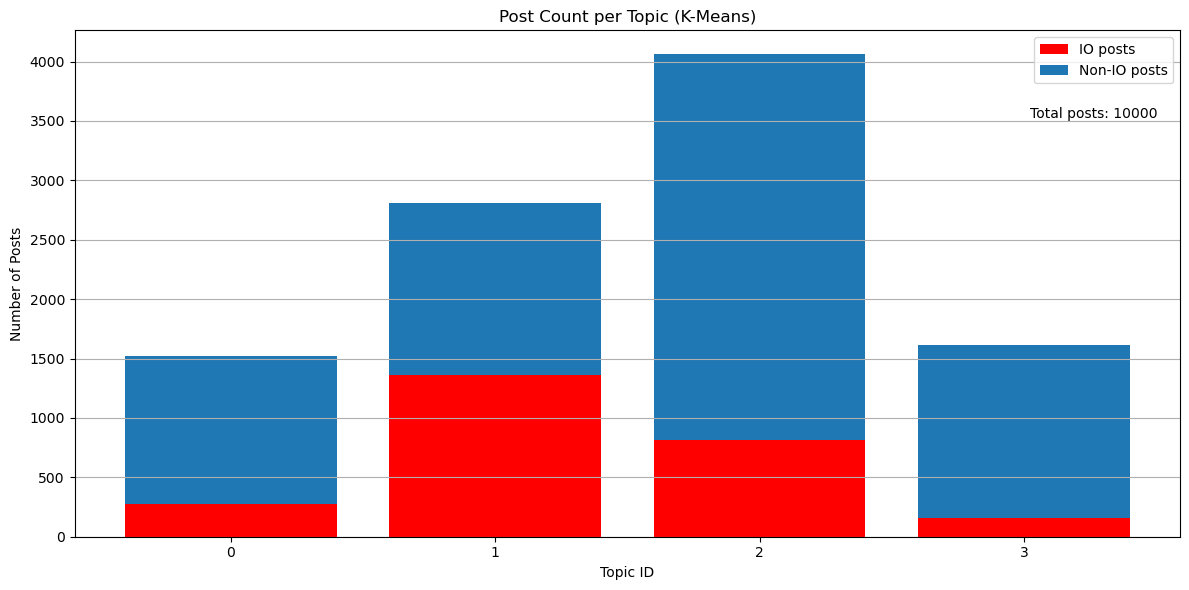

In [ ]:
topic_col_name = "K_Means_topic"
topic_stats = make_topic_stats(df, topic_col_name)
plot_topic_stats(topic_stats, topic_col_name, "K-Means", output_folder_path)

# Named Entity Recognition (NER)

In [ ]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

# Load model ONCE
tokenizer = AutoTokenizer.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")
ner_model = AutoModelForTokenClassification.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")

ner_pipeline = pipeline(
    "token-classification",
    model=ner_model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)


def extract_ner_entities(posts_lst: list):
    """
    Runs NER in batches on a list of text posts.

    Args:
          posts_lst (list): List of strings (cleaned posts).
    Returns
    -------
    all_entities (list[list[str]]): For each post: a list of extracted entity words.
    """

    ner_outputs = ner_pipeline(posts_lst)
    all_entities = []
    for post_output in ner_outputs:
        words = [ent["word"] for ent in post_output]
        all_entities.append(words)

    return all_entities

Device set to use cuda:0


In [ ]:
# Apply ONCE, no pandas apply, in order to utilize batches.
df["ner_entities"] = extract_ner_entities(df["clean_post_text"].to_list())

In [ ]:
df.loc[df["ner_entities"].astype(bool), ["clean_post_text", "ner_entities"]].head()

# Entities Statistics

In [ ]:
import pandas as pd

def compute_entity_topic_matrix(df, entity_col="entities", topic_col="topic_id", is_control_col="is_control"):
    """
    Create a df where values = number of times the entity appears in each topic.

    Args:
        df (pd.DataFrame):
            DataFrame containing posts, entity lists, topic labels and is_control.
        entity_col (str):
            Column containing a list of entities per post.
        topic_col (str):
            Column containing topic labels.
        is_control_col (str):
            Boolean column: True = legitimate, False = IO.

    Returns:
        entity_topic_counts (pd.DataFrame):
            Columns:
                [entity, total_count, io_percent, topic_ids = 1, 2, 3...]
    """

    # 1) Explode entity lists → one row per (entity, topic, is_control)
    df_exp = (
        df[[entity_col, topic_col, is_control_col]]
        .explode(entity_col)
        .dropna(subset=[entity_col])
        .copy()
    )

    # 2) Aggregate counts per entity (overall)
    entity_stats = (
        df_exp.groupby(entity_col)
              .agg(
                  total_count=(entity_col, "count"),
                  io_count=(is_control_col, lambda x: (~x).sum()),  # False = IO
              )
              .reset_index()
    )
    entity_stats["io_percent"] = 100 * entity_stats["io_count"] / entity_stats["total_count"]
    entity_stats = entity_stats[[entity_col, "total_count", "io_percent"]]

    # 3) Count occurrences per (entity, topic)
    entity_topic_counts = (
        df_exp.groupby([entity_col, topic_col])
              .size()
              .reset_index(name="count")
    )

    # 4) Pivot to wide format (entity rows × topic columns)
    entity_topic_counts = (
        entity_topic_counts
        .pivot_table(
            index=entity_col,
            columns=topic_col,
            values="count",
            fill_value=0
        )
        .sort_index(axis=1)   # ensure topic columns sorted: 0,1,2,...
        .reset_index()
    )

    # 5) Merge total_count + IO stats
    entity_topic_counts = entity_stats.merge(entity_topic_counts, on=entity_col, how="left")

    # 6) Sort by total_count (descending)
    entity_topic_counts = entity_topic_counts.sort_values("total_count", ascending=False)

    return entity_topic_counts

In [ ]:
import matplotlib.pyplot as plt

def plot_entity_topic_distribution(entity, entity_topic_counts, clustering_model="", output_folder_path=None):
    """
    Plot how many times a given entity appears in each topic.

    Args:
        entity (str): The entity to plot.
        entity_topic_counts (pd.DataFrame): Output of compute_entity_topic_matrix().
        clustering_model (str): Name of the clustering model (just for show).
        output_folder_path (Path or str): Where to save the plot (optional).

    Returns:
        None
    """

    # Extract row for chosen entity
    row = entity_topic_df[entity_topic_df["entities"] == entity]

    # Keep only topic columns (numbers)
    topic_cols = [c for c in entity_topic_df.columns if isinstance(c, int)]
    counts = row[topic_cols].iloc[0]

    # --- Plot ---
    plt.figure(figsize=(12, 5))
    plt.bar(topic_cols, counts)

    plt.title(f"Topic Distribution for Entity: '{entity}'")
    plt.xlabel("Topic ID")
    plt.ylabel("Count of occurrences")
    plt.text(0.98, 0.82, f"clustering model: {clustering_model}", ha="right", va="bottom", transform=plt.gca().transAxes)
    plt.xticks(topic_cols)
    plt.tight_layout()

    # Save if path provided
    if output_folder_path:
        out_file = Path(output_folder_path) / f"entity_{entity}_topic_distribution.png"
        plt.savefig(out_file, dpi=300)
        print(f"Saved to {out_file}")

    plt.show()

In [ ]:
BERT_entity_topic_matrix = compute_entity_topic_matrix(df, entity_col="ner_entities", topic_col="BERTopic_topic")
display(BERT_entity_topic_matrix.head())

In [ ]:
entity = BERT_entity_topic_matrix["entities"].iloc[0]   # first entity
plot_entity_topic_distribution(entity, BERT_entity_topic_matrix, "BERTopic", output_folder_path)

# Save to parquet

In [ ]:
# print dataset statistics
for col in df.columns:
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")

In [ ]:
df_output_path = output_folder_path / f"Topic_Ner_{file_name}"

df.to_parquet(df_output_path, index=False, compression="gzip")
print("df is saved to:", df_output_path)